# Assignment 6 - MOEA Convergence & Reference Set Construction

**Course:** EPA141A Model-Based Decision Making - Delft University of Technology  
**Model:** JUSTICE  

---

## Learning Outcomes

After completing this assignment you will be able to:

1. Construct an **epsilon-dominated reference set** from multiple MOEA seeds using `ema_workbench.em_framework.optimization.epsilon_nondominated`.
2. Compute and interpret **hypervolume**, **epsilon-progress**, **generational distance**, and **epsilon indicator** as MOEA quality indicators.
3. Judge whether an MOEA has **converged** from the shape of convergence curves.

---

## Background

### Convergence vs. quality

Two separate questions must be answered before trusting MOEA results:

| Question | Metric | Good sign |
|----------|--------|-----------|
| Did the algorithm **converge**? | Epsilon-progress, hypervolume over NFE | Plateau reached well before NFE is exhausted |
| Is the Pareto front **good**? | Hypervolume, GD, epsilon indicator | High HV, low GD, low EI |


---

## Overview

This assignment analyses the results from Assignment 5. You will:

1. **Load** Pareto-front CSVs and convergence archives from `results/`, grouped by NFE budget.
2. **Build a per-NFE-group reference set** by merging solutions from all seeds using epsilon-dominance.
3. **Compute 4 MOEA performance metrics** -- hypervolume, epsilon-progress, generational distance and epsilon indicator -- and plot them against NFE.

## Setup — Imports and model configuration

The cell below imports all required packages, applies a Python 3.14 compatibility patch for `matplotlib.path.Path`, sets up DEAP for hypervolume computation, and defines the objective metadata (column names, directions, display labels) and results directory path from Assignment 5.

In [9]:
%pip install --upgrade --force-reinstall "deap==1.4.3"

  Using cached deap-1.4.3-cp312-cp312-macosx_10_13_universal2.whl.metadata (13 kB)
  Using cached numpy-2.4.6-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached deap-1.4.3-cp312-cp312-macosx_10_13_universal2.whl (111 kB)
Using cached numpy-2.4.6-cp312-cp312-macosx_14_0_arm64.whl (5.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
  Attempting uninstall: deap━━━━━━━━━━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: deap 1.4.3━ 0/2 [numpy]
    Uninstalling deap-1.4.3:━━━━━━━━━━━━━━━━ 0/2 [numpy]
      Successfully uninstalled deap-1.4.3━━━ 0/2 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [deap]1/2 [deap]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
justice 1.0.0 requires gymnasium==0.28.1, which is not installed.
justice 1.0

In [17]:
# Standard imports
import warnings
warnings.filterwarnings("ignore")

import os, sys, json, glob, copy
import numpy as np
import pandas as pd

# Matplotlib deepcopy patch (Python 3.14 + matplotlib compatibility)
import matplotlib.path as _mpath

def _fixed_path_deepcopy(self, memo):
    cls   = type(self)
    verts = copy.deepcopy(self.vertices, memo)
    codes = copy.deepcopy(self.codes, memo) if self.codes is not None else None
    new   = cls.__new__(cls)
    new.__init__(verts, codes)
    return new

_mpath.Path.__deepcopy__ = _fixed_path_deepcopy

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# DEAP hypervolume 
from deap.tools._hypervolume import hv as deap_hv

# EMA Workbench 
from ema_workbench.em_framework.optimization import (
    epsilon_nondominated,
    Problem,
)
from ema_workbench import RealParameter, ScalarOutcome

#  This version skips None entries.
import tarfile as _tarfile
import io as _io

def load_archives(path_to_file):
    """Load convergence archives (handles both ema_workbench 2.x and 3.0 formats).
    
    New format (3.0): plain tar, files at root level (0.csv, 502.csv...)
    Both: r:* auto-detects compression; NFE extracted from basename stem.
    """
    archives = []
    import pandas as _pd
    with _tarfile.open(path_to_file, "r:*") as archive:
        for fn in archive.getnames():
            f = archive.extractfile(fn)
            if f is None:
                continue  # skip directory entries
            basename = fn.split("/")[-1]
            try:
                nfe = int(basename.split(".")[0])
            except ValueError:
                continue
            data = _pd.read_csv(f)
            archives.append((nfe, data))
    return archives

# EMA Workbench -- GD and EI metrics (Platypus-based)
from ema_workbench.em_framework.optimization_convergence import (
    GenerationalDistanceMetric,
    EpsilonIndicatorMetric,
)

# Path setup
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')
_JUSTICE_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../JUSTICE-main"))

if _JUSTICE_ROOT not in sys.path:
    sys.path.insert(0, _JUSTICE_ROOT)

os.chdir(_JUSTICE_ROOT)

RESULTS_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "results"))

# Objective metadata
OBJECTIVE_COLS  = ["welfare", "fraction_above_threshold",
                   "welfare_loss_damage", "welfare_loss_abatement"]
MAXIMIZE_COLS   = ["welfare_loss_damage", "welfare_loss_abatement"]
MINIMIZE_COLS   = ["welfare", "fraction_above_threshold"]
OBJECTIVE_LABELS = {
    "welfare":                  "Welfare loss\n(MINIMIZE)",
    "fraction_above_threshold": "Fraction above\n2 C in 2100\n(MINIMIZE)",
    "welfare_loss_damage":      "Welfare loss\nfrom damage\n(MAXIMIZE)",
    "welfare_loss_abatement":   "Welfare loss\nfrom abatement\n(MAXIMIZE)",
}

# DEAP hypervolume helpers
# DEAP requires pure minimisation — MAXIMIZE objectives are negated
_NEGATE = {col: (col in MAXIMIZE_COLS) for col in OBJECTIVE_COLS}

def _deap_hypervolume(archive_df, ref_point):
    """Compute hypervolume using DEAP's WFG algorithm (pure minimisation).
    MAXIMIZE objectives are negated before computation.
    ref_point must strictly dominate all converted points.
    """
    pts = archive_df[OBJECTIVE_COLS].copy()
    for col, neg in _NEGATE.items():
        if neg:
            pts[col] = -pts[col]
    return deap_hv.hypervolume(pts.values.tolist(), ref_point)

def _compute_ref_point(ref_df, margin=0.1):
    """Build a reference point strictly dominated by all solutions.
    For each axis (after minimisation conversion): max + margin * range.
    """
    pts = ref_df[OBJECTIVE_COLS].copy()
    for col, neg in _NEGATE.items():
        if neg:
            pts[col] = -pts[col]
    rp = []
    for col in OBJECTIVE_COLS:
        hi = pts[col].max()
        lo = pts[col].min()
        rp.append(hi + margin * max(hi - lo, 1e-6))
    return rp

print(f"JUSTICE root : {_JUSTICE_ROOT}")
print(f"Results root : {RESULTS_ROOT}")
print("DEAP hypervolume + EMA Workbench GD/EI metrics : OK")

JUSTICE root : /Users/finnmaingay/epa141a/JUSTICE-main
Results root : /Users/finnmaingay/epa141a/assignments_ema/results
DEAP hypervolume + EMA Workbench GD/EI metrics : OK


---

## Step 1 — Load Results from Assignment 5

Scan `results/` for Pareto-front CSVs, convergence archives, and convergence CSVs.  
Directories are named `<welfare_function>_<nfe>_<seed>/`, so we can recover the NFE directly
from the directory name and group all data by it.

Each seed directory contains:
- `pareto_front_<seed>.csv` — final Pareto-optimal solutions (levers + objectives)
- `<welfare_function>_<nfe>_<seed>.tar.gz` — archive snapshots (ArchiveLogger output)
- `convergence_<seed>.csv` — EpsilonProgress & operator probabilities (EMA Workbench)


In [18]:
# ── Discover Pareto-front CSVs — grouped by NFE ───────────────────────────────
csv_paths = sorted(glob.glob(
    os.path.join(RESULTS_ROOT, "**", "pareto_front_*.csv"), recursive=True
))

if not csv_paths:
    raise FileNotFoundError(
        f"No pareto_front_*.csv found in {RESULTS_ROOT}.\n"
        "Run Assignment 5 (run_optimization_local.py) first."
    )

# nfe_groups[nfe][seed] = DataFrame
nfe_groups = {}
for path in csv_paths:
    dir_name = os.path.basename(os.path.dirname(path))
    parts    = dir_name.split("_")
    try:
        nfe  = int(parts[-2])
        seed = int(parts[-1])
    except (ValueError, IndexError):
        seed = int(os.path.basename(path).replace("pareto_front_", "").replace(".csv", ""))
        nfe  = 0
    df = pd.read_csv(path)
    df = df[df["welfare"] < 1e5].reset_index(drop=True)
    nfe_groups.setdefault(nfe, {})[seed] = df

# ── Discover convergence archives — keyed by (nfe, seed) ─────────────────────
archive_paths = sorted(glob.glob(
    os.path.join(RESULTS_ROOT, "**", "UTILITARIAN_*.tar.gz"), recursive=True
))

nfe_seed_archives = {}   # (nfe, seed) → path
for p in archive_paths:
    parts    = os.path.basename(p).replace(".tar.gz", "").split("_")
    seed_val = int(parts[-1])
    nfe_val  = int(parts[-2])
    nfe_seed_archives[(nfe_val, seed_val)] = p

# ── Discover convergence CSVs — keyed by (nfe, seed) ─────────────────────────
# Saved by run_optimization_local.py as results/<welfare_function>_<nfe>_<seed>/convergence_<seed>.csv
conv_csv_paths = sorted(glob.glob(
    os.path.join(RESULTS_ROOT, "**", "convergence_*.csv"), recursive=True
))

nfe_seed_convergence = {}   # (nfe, seed) → DataFrame
for p in conv_csv_paths:
    dir_name = os.path.basename(os.path.dirname(p))
    parts    = dir_name.split("_")
    try:
        nfe_val  = int(parts[-2])
        seed_val = int(parts[-1])
    except (ValueError, IndexError):
        seed_val = int(os.path.basename(p).replace("convergence_", "").replace(".csv", ""))
        nfe_val  = 0
    df_conv = pd.read_csv(p, index_col=0)
    nfe_seed_convergence[(nfe_val, seed_val)] = df_conv

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"NFE groups found: {sorted(nfe_groups)}")
print()
rows = []
for nfe in sorted(nfe_groups):
    for seed, df in sorted(nfe_groups[nfe].items()):
        rows.append({
            "nfe_budget":      nfe,
            "seed":            seed,
            "n_solutions":     len(df),
            "has_archive":     (nfe, seed) in nfe_seed_archives,
            "has_conv_csv":    (nfe, seed) in nfe_seed_convergence,
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print(f"\n{len(nfe_seed_archives)} archive(s) | {len(nfe_seed_convergence)} convergence CSV(s)")


NFE groups found: [5, 20, 500, 1500, 2000, 5000, 20000, 50000]

 nfe_budget    seed  n_solutions  has_archive  has_conv_csv
          5       1            1         True          True
          5       2            1         True          True
          5       3            1         True          True
          5       4            1         True          True
          5       5            1         True          True
         20       1            1         True          True
         20       2            1         True          True
         20       3            1         True          True
         20       4            1         True          True
         20       5            1         True          True
        500       1            7         True          True
       1500      99            1        False          True
       2000       1            1        False          True
       2000       2            1         True          True
       2000       3            1    

## What is a reference set?

A reference set is the best collection of non-dominated solutions found across all your optimisation runs — all seeds, all NFEs combined into one Pareto front. It represents the most complete picture of the trade-off frontier your algorithm was able to discover.

The reference set serves two distinct purposes in this assignment:

1. As a benchmark for convergence metrics
Generational Distance (GD) and Epsilon Indicator (EI) measure how close each seed's archive is to the reference set at each point in the optimisation. Without a reference set you have no target to measure distance from.

2. As input for Assignments 7 and 8
The grand reference set (pooled across all seeds and NFE budgets) is saved to CSV and loaded directly in the visualisation and robustness assignments. It is the agreed-upon "best known" Pareto front for your welfare function that the rest of the analysis is built on.


If you tested different  NFE budgets (e.g. 500 NFE, 20 000 NFE) each gets its own reference set.

Each reference set is saved as `reference_set_<welfare_function>_<nfe>.csv`, if you are first comparing results across different nfes. For computing the grand reference set, simply name it `reference_set_<welfare_function>.csv`

We use `ema_workbench.em_framework.optimization.epsilon_nondominated`, which internally
calls Platypus's `EpsilonBoxArchive`.  Docs: https://emaworkbench.readthedocs.io/en/latest/ema_documentation/em_framework/optimization.html#ema_workbench.em_framework.optimization.epsilon_nondominated


In [19]:
from ema_workbench import RealParameter, ScalarOutcome
from ema_workbench.em_framework.optimization import epsilon_nondominated, Problem

WELFARE_FUNCTION = "utilitarian"
EPSILONS = [10.0, 0.1, 10.0, 10.0]

outcomes = [
    ScalarOutcome("welfare",                  kind=ScalarOutcome.MINIMIZE),
    ScalarOutcome("fraction_above_threshold", kind=ScalarOutcome.MINIMIZE),
    ScalarOutcome("welfare_loss_damage",      kind=ScalarOutcome.MAXIMIZE),
    ScalarOutcome("welfare_loss_abatement",   kind=ScalarOutcome.MAXIMIZE),
]

metadata_cols = ["seed", "nfe", "run_dir"]
reference_sets_by_nfe = {}

for nfe, seed_dfs in sorted(nfe_groups.items()):
    archives = []

    for seed, df in sorted(seed_dfs.items()):
        df = df.copy()
        df["seed"] = seed
        df["nfe"] = nfe
        archives.append(df)

    merged = pd.concat(archives, ignore_index=True)
    merged = merged.replace([np.inf, -np.inf], np.nan)
    merged = merged.dropna(subset=OBJECTIVE_COLS).reset_index(drop=True)

    lever_cols = [
        col for col in merged.columns
        if col not in OBJECTIVE_COLS + metadata_cols
    ]

    safe_name_map = {col: col.replace(" ", "_") for col in lever_cols}
    reverse_safe_name_map = {v: k for k, v in safe_name_map.items()}

    archive_for_ema = merged[lever_cols + OBJECTIVE_COLS].copy()
    archive_for_ema = archive_for_ema.rename(columns=safe_name_map)

    safe_lever_cols = [safe_name_map[col] for col in lever_cols]

    levers = []
    for col in safe_lever_cols:
        lo = float(archive_for_ema[col].min())
        hi = float(archive_for_ema[col].max())

        if lo == hi:
            hi = lo + 1e-12

        levers.append(RealParameter(col, lo, hi))

    problem = Problem("levers", levers, outcomes)

    reference_set = epsilon_nondominated(
        [archive_for_ema],
        EPSILONS,
        problem,
    ).reset_index(drop=True)

    reference_set = reference_set.rename(columns=reverse_safe_name_map)

    reference_sets_by_nfe[nfe] = reference_set

    ref_path = os.path.join(
        RESULTS_ROOT,
        f"reference_set_{WELFARE_FUNCTION}_{nfe}.csv"
    )
    reference_set.to_csv(ref_path, index=False)

    print(
        f"NFE {nfe}: merged {len(merged)} solutions "
        f"-> reference set {len(reference_set)} solutions"
    )
    print(f"Saved: {ref_path}")

# Grand reference set across all NFE budgets
all_reference_candidates = pd.concat(
    reference_sets_by_nfe.values(),
    ignore_index=True,
)

# Remove duplicate columns if they exist
all_reference_candidates = all_reference_candidates.loc[
    :, ~all_reference_candidates.columns.duplicated()
]

lever_cols = [
    col for col in all_reference_candidates.columns
    if col not in OBJECTIVE_COLS + metadata_cols
]

# Make safe names, but also make them unique
safe_name_map = {}
used_names = set()

for col in lever_cols:
    safe = col.replace(" ", "_")

    if safe in used_names:
        i = 1
        new_safe = f"{safe}_{i}"
        while new_safe in used_names:
            i += 1
            new_safe = f"{safe}_{i}"
        safe = new_safe

    safe_name_map[col] = safe
    used_names.add(safe)

reverse_safe_name_map = {v: k for k, v in safe_name_map.items()}

archive_for_ema = all_reference_candidates[lever_cols + OBJECTIVE_COLS].copy()
archive_for_ema = archive_for_ema.rename(columns=safe_name_map)

safe_lever_cols = [safe_name_map[col] for col in lever_cols]

levers = []

for col in safe_lever_cols:
    values = pd.to_numeric(archive_for_ema[col], errors="coerce")

    lo = float(values.min())
    hi = float(values.max())

    if lo == hi:
        hi = lo + 1e-12

    levers.append(RealParameter(col, lo, hi))

problem = Problem("levers", levers, outcomes)

grand_reference_set = epsilon_nondominated(
    [archive_for_ema],
    EPSILONS,
    problem,
).reset_index(drop=True)

grand_reference_set = grand_reference_set.rename(columns=reverse_safe_name_map)

grand_ref_path = os.path.join(
    RESULTS_ROOT,
    f"reference_set_{WELFARE_FUNCTION}.csv"
)

grand_reference_set.to_csv(grand_ref_path, index=False)

print("\nGrand reference set:")
print(
    f"pooled {len(all_reference_candidates)} NFE-level reference candidates "
    f"-> {len(grand_reference_set)} solutions"
)
print(f"Saved: {grand_ref_path}")

print("\nGrand reference set objective summary:")
print(grand_reference_set[OBJECTIVE_COLS].describe().round(3))

NFE 5: merged 5 solutions -> reference set 1 solutions
Saved: /Users/finnmaingay/epa141a/assignments_ema/results/reference_set_utilitarian_5.csv
NFE 20: merged 5 solutions -> reference set 1 solutions
Saved: /Users/finnmaingay/epa141a/assignments_ema/results/reference_set_utilitarian_20.csv
NFE 500: merged 7 solutions -> reference set 6 solutions
Saved: /Users/finnmaingay/epa141a/assignments_ema/results/reference_set_utilitarian_500.csv
NFE 1500: merged 1 solutions -> reference set 1 solutions
Saved: /Users/finnmaingay/epa141a/assignments_ema/results/reference_set_utilitarian_1500.csv
NFE 2000: merged 5 solutions -> reference set 1 solutions
Saved: /Users/finnmaingay/epa141a/assignments_ema/results/reference_set_utilitarian_2000.csv
NFE 5000: merged 5 solutions -> reference set 1 solutions
Saved: /Users/finnmaingay/epa141a/assignments_ema/results/reference_set_utilitarian_5000.csv
NFE 20000: merged 46 solutions -> reference set 8 solutions
Saved: /Users/finnmaingay/epa141a/assignments_

---

## Step 3 — MOEA Performance Metrics - pre-processing

We compute four convergence / quality metrics from the `load_archives` snapshots, one per NFE group:

| Metric | What it measures | Tool | Direction |
|--------|-----------------|------|-----------|
| **Hypervolume (HV)** | Volume of objective space dominated by the archive | `HypervolumeMetric` | higher = better |
| **Epsilon-progress** | Change in archive size per generation | EMA Workbench convergence CSV | positive = still improving |
| **Generational Distance (GD)** | Mean distance from archive solutions to the group reference set | `GenerationalDistanceMetric` | lower = better |
| **Epsilon Indicator (EI)** | Additive epsilon needed so result epsilon-dominates the group reference set | `EpsilonIndicatorMetric` | lower = better; 0 = full dominance |


**Task 3.1** -- After running all three cells below, answer the reflection questions at the bottom of this notebook.

**Task 3.2** -- For each metric, identify the approximate NFE at which convergence occurs (if it does). Summarise in a table.

In [20]:
# This cell loads the convergence archives produced by run_optimization_local.py.
# Each archive contains snapshots of the Pareto front taken at intervals during the run —
# this is what allows you to track whether the MOEA had converged by the end.
#
# load_archives() reads the .tar.gz archive
# and returns a list of (checkpoint_nfe, DataFrame) pairs, one per snapshot.
# We convert this to a dict keyed by checkpoint NFE for easy lookup.
#
# Run this cell as-is. The output tells you how many snapshots were saved per run
# and how many solutions were in the final archive
# Load convergence archives -- keyed by (nfe, seed)
if not nfe_seed_archives:
    print("No convergence archives found -- skipping metric computation.")
else:
    # all_snapshots[(nfe, seed)] = {checkpoint_nfe: DataFrame}
    all_snapshots = {}

    for (nfe, seed), path in sorted(nfe_seed_archives.items()):
        print(f"  Loading: NFE={nfe:,}  seed={seed} ...", end=" ")
        # load_archives returns list[tuple[int, DataFrame]] in ema_workbench 3.0
        snaps = dict(load_archives(path))
        snaps = {
            n: df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")],
                       errors="ignore")
            for n, df in snaps.items()
        }
        all_snapshots[(nfe, seed)] = snaps
        max_n = max(snaps)
        print(f"{len(snaps)} snapshots | final archive = {len(snaps[max_n])} solutions @ NFE {max_n:,}")

    print(f"\n{len(all_snapshots)} archive(s) loaded.")

  Loading: NFE=5  seed=1 ... 1 snapshots | final archive = 1 solutions @ NFE 100
  Loading: NFE=5  seed=2 ... 1 snapshots | final archive = 1 solutions @ NFE 100
  Loading: NFE=5  seed=3 ... 1 snapshots | final archive = 1 solutions @ NFE 100
  Loading: NFE=5  seed=4 ... 1 snapshots | final archive = 1 solutions @ NFE 100
  Loading: NFE=5  seed=5 ... 1 snapshots | final archive = 1 solutions @ NFE 100
  Loading: NFE=20  seed=1 ... 1 snapshots | final archive = 1 solutions @ NFE 100
  Loading: NFE=20  seed=2 ... 1 snapshots | final archive = 1 solutions @ NFE 100
  Loading: NFE=20  seed=3 ... 1 snapshots | final archive = 1 solutions @ NFE 100
  Loading: NFE=20  seed=4 ... 1 snapshots | final archive = 1 solutions @ NFE 100
  Loading: NFE=20  seed=5 ... 1 snapshots | final archive = 1 solutions @ NFE 100
  Loading: NFE=500  seed=1 ... 1 snapshots | final archive = 8 solutions @ NFE 501
  Loading: NFE=2,000  seed=2 ... 2 snapshots | final archive = 1 solutions @ NFE 2,008
  Loading: NFE=

## Step 4 -  Computing and visualizing convergence metrics

Compute and visualize MOEA convergence metrics, check the following for guidance: 

https://emaworkbench.readthedocs.io/en/latest/examples/optimization_convergence_analysis.html#Convergence-metrics


In [14]:
# --- YOUR TASK ---
# For each seed and NFE budget, compute Pareto front quality metrics
# at every archive snapshot and store the results 
#
# The snapshots are in all_snapshots — each entry contains the Pareto archive
# as it looked at a specific point during the optimisation run.
# By computing metrics at each snapshot you can track whether the algorithm
# converged before the NFE budget was exhausted.
#
# Sample metrics to compute:
#   - Hypervolume (HV)           — how much of the objective space is dominated
#   - Generational Distance (GD) — how close the archive is to the reference set
#   - Epsilon Indicator (EI)     — how much the reference set still dominates the archive
#   - Epsilon-progress (eps)     — how many new solutions were added at each checkpoint
#
#Store your results
#
# Hint: check the ema_workbench convergence metrics documentation and the
# _deap_hypervolume() function defined in the setup cell. 


# YOUR CODE HERE — compute metrics

# ── Visualisation ─────────────────────────────────────────────────────────────
# Create one figure per NFE budget with four panels, one per metric (HV, GD, EI, eps).
# Plot NFE on the x-axis and the metric value on the y-axis.
# Show all seeds on the same panel
#
# YOUR CODE HERE — plot



In [21]:
# ── Compute Convergence Metrics ──────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "all_snapshots" not in globals() or not all_snapshots:
    raise RuntimeError("No archive snapshots found. Run the archive-loading cell first.")

def _to_minimisation(df):
    """Convert mixed MIN/MAX objectives to pure minimisation space."""
    pts = df[OBJECTIVE_COLS].copy()
    for col in MAXIMIZE_COLS:
        pts[col] = -pts[col]
    return pts.astype(float)

def _normalise_against_reference(pts, ref_pts):
    """Normalise objective values using the reference-set range."""
    lo = ref_pts.min()
    hi = ref_pts.max()
    span = (hi - lo).replace(0, 1e-12)
    return (pts - lo) / span

def generational_distance(archive_df, ref_df):
    """Mean distance from archive points to nearest reference-set point."""
    archive = _to_minimisation(archive_df)
    ref = _to_minimisation(ref_df)

    archive = _normalise_against_reference(archive, ref).values
    ref = _normalise_against_reference(ref, ref).values

    distances = []
    for point in archive:
        distances.append(np.min(np.linalg.norm(ref - point, axis=1)))

    return float(np.mean(distances))

def epsilon_indicator(archive_df, ref_df):
    """
    Additive epsilon indicator in minimisation space.
    Lower is better; 0 or below means the archive weakly dominates the reference set.
    """
    archive = _to_minimisation(archive_df)
    ref = _to_minimisation(ref_df)

    archive = _normalise_against_reference(archive, ref).values
    ref = _normalise_against_reference(ref, ref).values

    eps_values = []
    for r in ref:
        eps_values.append(np.min(np.max(archive - r, axis=1)))

    return float(np.max(eps_values))

metric_rows = []

for (nfe_budget, seed), snapshots in sorted(all_snapshots.items()):
    if nfe_budget in reference_sets_by_nfe:
        ref_set = reference_sets_by_nfe[nfe_budget]
    else:
        ref_set = grand_reference_set

    # Build HV reference point from all snapshots plus the reference set,
    # so it is safely worse than all observed archives.
    hv_basis = pd.concat(
        [ref_set] + [df for df in snapshots.values()],
        ignore_index=True,
    )
    hv_ref_point = _compute_ref_point(hv_basis)

    previous_archive_size = None

    for checkpoint_nfe, archive_df in sorted(snapshots.items()):
        archive_df = archive_df.replace([np.inf, -np.inf], np.nan)
        archive_df = archive_df.dropna(subset=OBJECTIVE_COLS)

        if archive_df.empty:
            continue

        archive_size = len(archive_df)

        if previous_archive_size is None:
            eps_progress = archive_size
        else:
            eps_progress = max(archive_size - previous_archive_size, 0)

        previous_archive_size = archive_size

        metric_rows.append({
            "nfe_budget": nfe_budget,
            "seed": seed,
            "nfe": checkpoint_nfe,
            "archive_size": archive_size,
            "hv": _deap_hypervolume(archive_df, hv_ref_point),
            "gd": generational_distance(archive_df, ref_set),
            "ei": epsilon_indicator(archive_df, ref_set),
            "eps": eps_progress,
        })

metrics = pd.DataFrame(metric_rows)

print("Convergence metrics computed:")
print(metrics.groupby(["nfe_budget", "seed"]).size().rename("n_snapshots"))
print("\nMetric summary:")
print(metrics[["hv", "gd", "ei", "eps"]].describe().round(4))

Convergence metrics computed:
nfe_budget  seed   
5           1           1
            2           1
            3           1
            4           1
            5           1
20          1           1
            2           1
            3           1
            4           1
            5           1
500         1           1
2000        2           2
            3           2
            4           2
            5           2
5000        1           5
            2           1
            3           5
            4           5
            5           5
20000       521475     20
            1644652    20
            3569126    20
            6075612    20
            9845531    20
50000       1           1
            2          21
Name: n_snapshots, dtype: int64

Metric summary:
                 hv            gd            ei       eps
count  1.620000e+02  1.620000e+02  1.620000e+02  162.0000
mean   3.932416e+13  1.206472e+15  2.111013e+14    0.5000
std    6.563705e+13  1.53

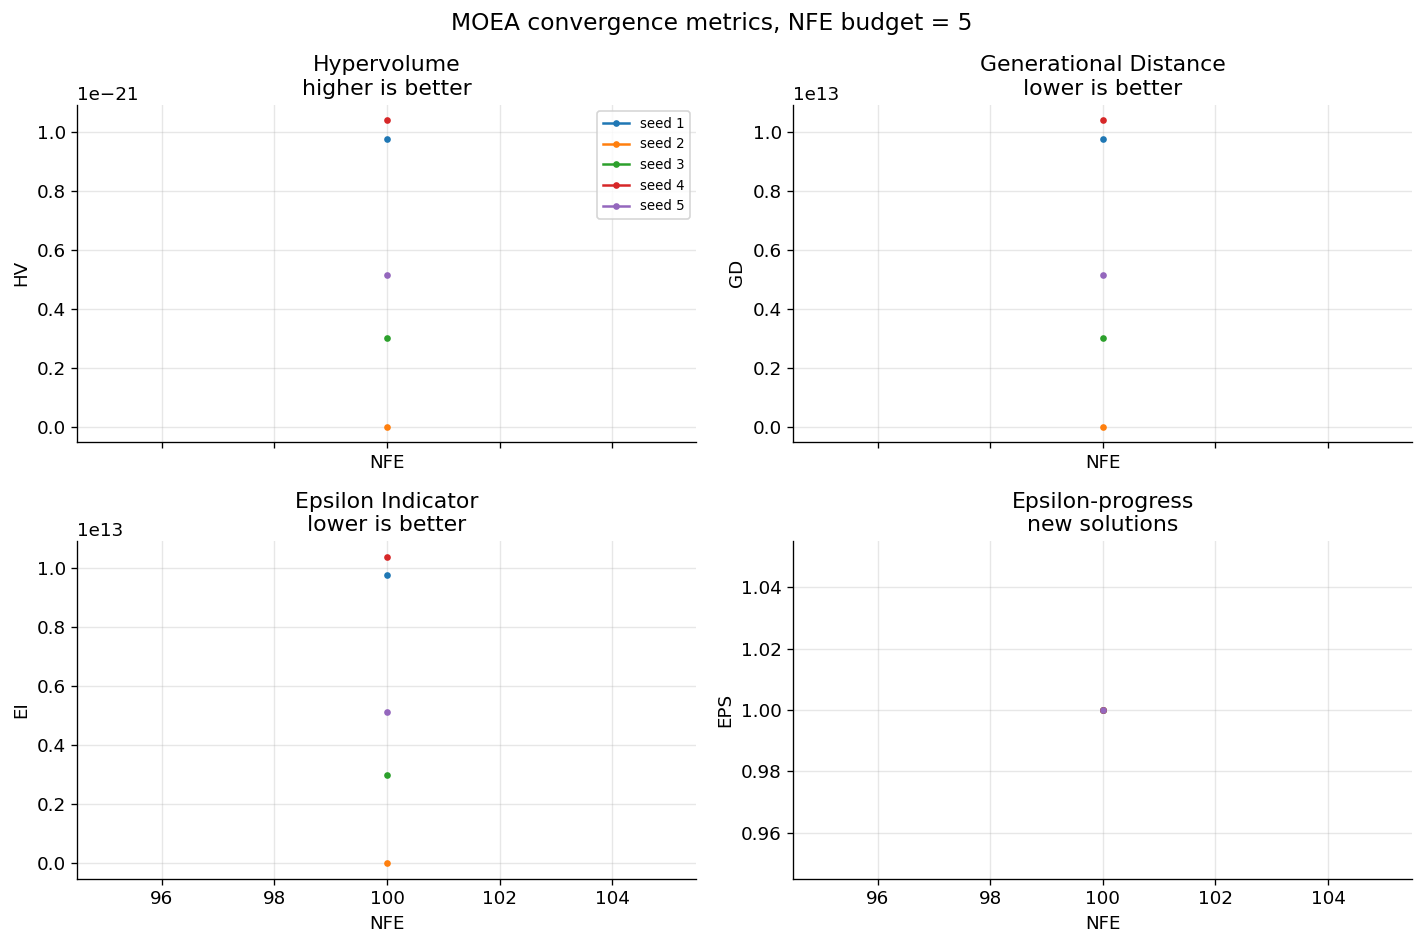

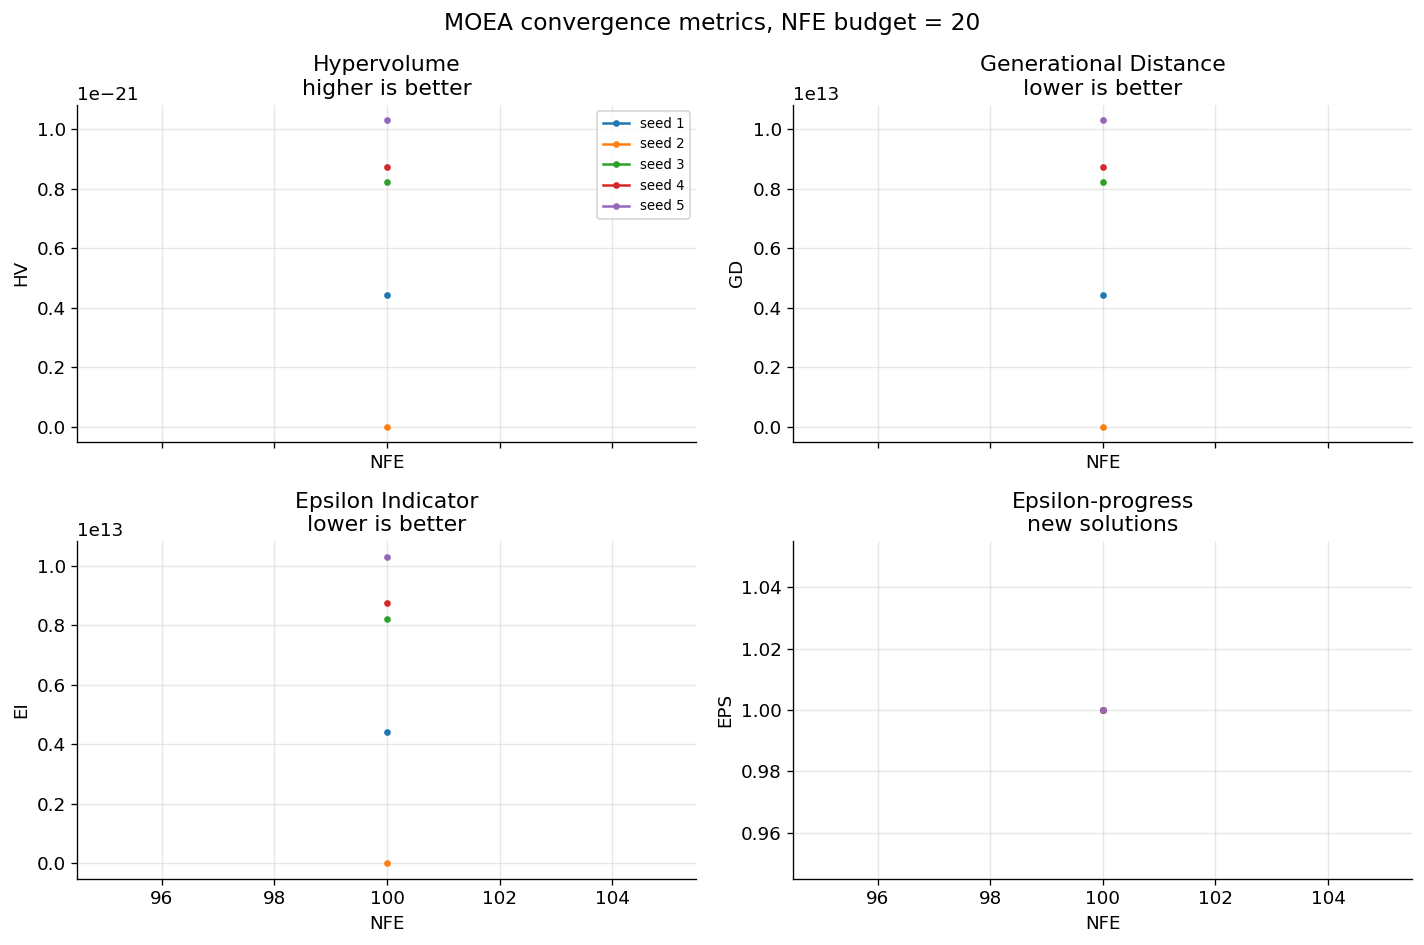

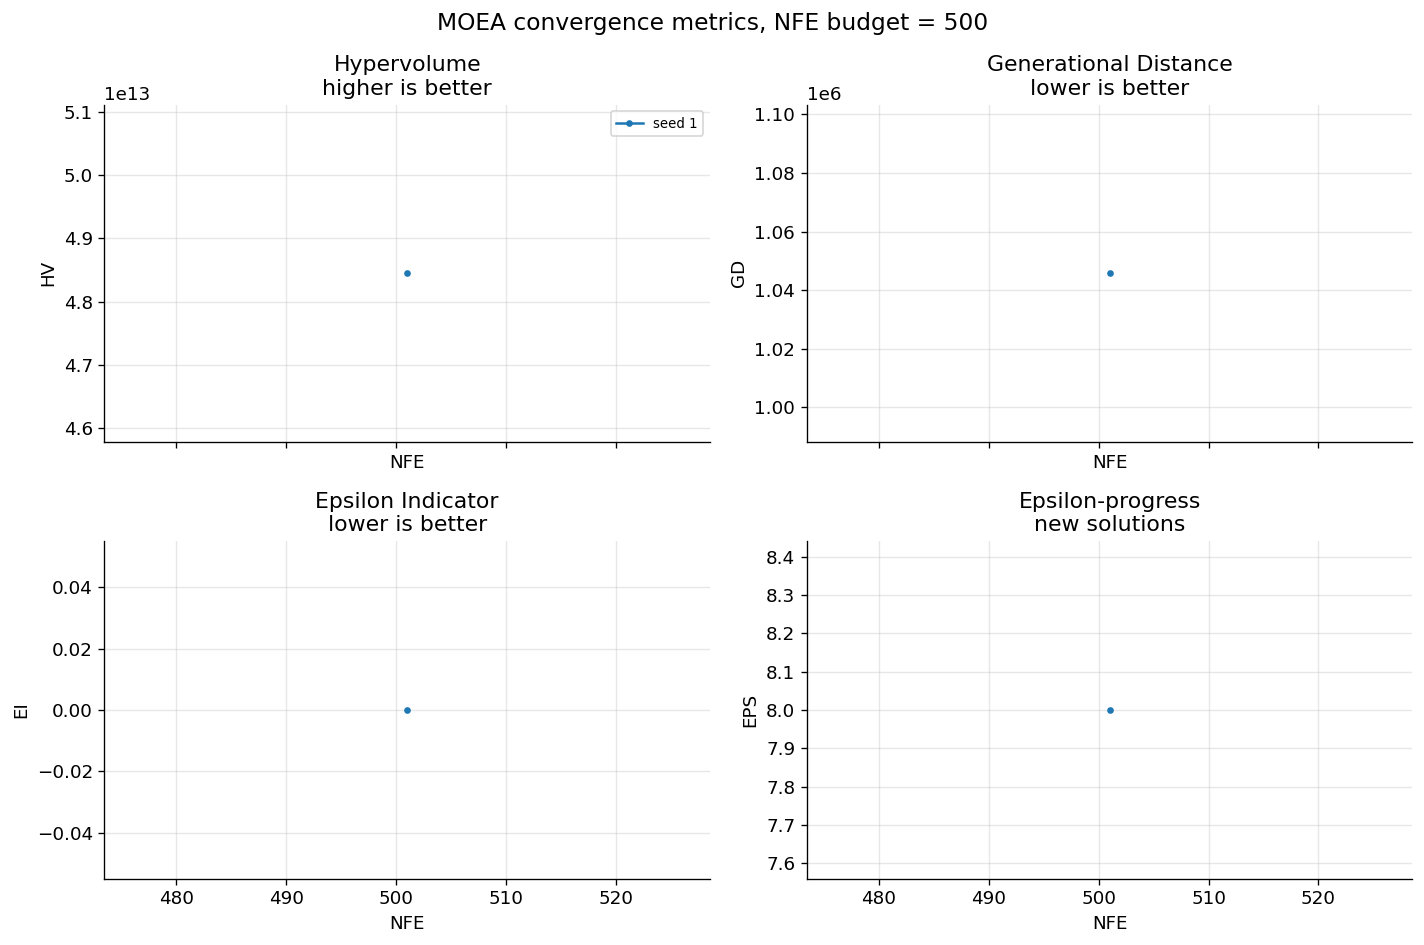

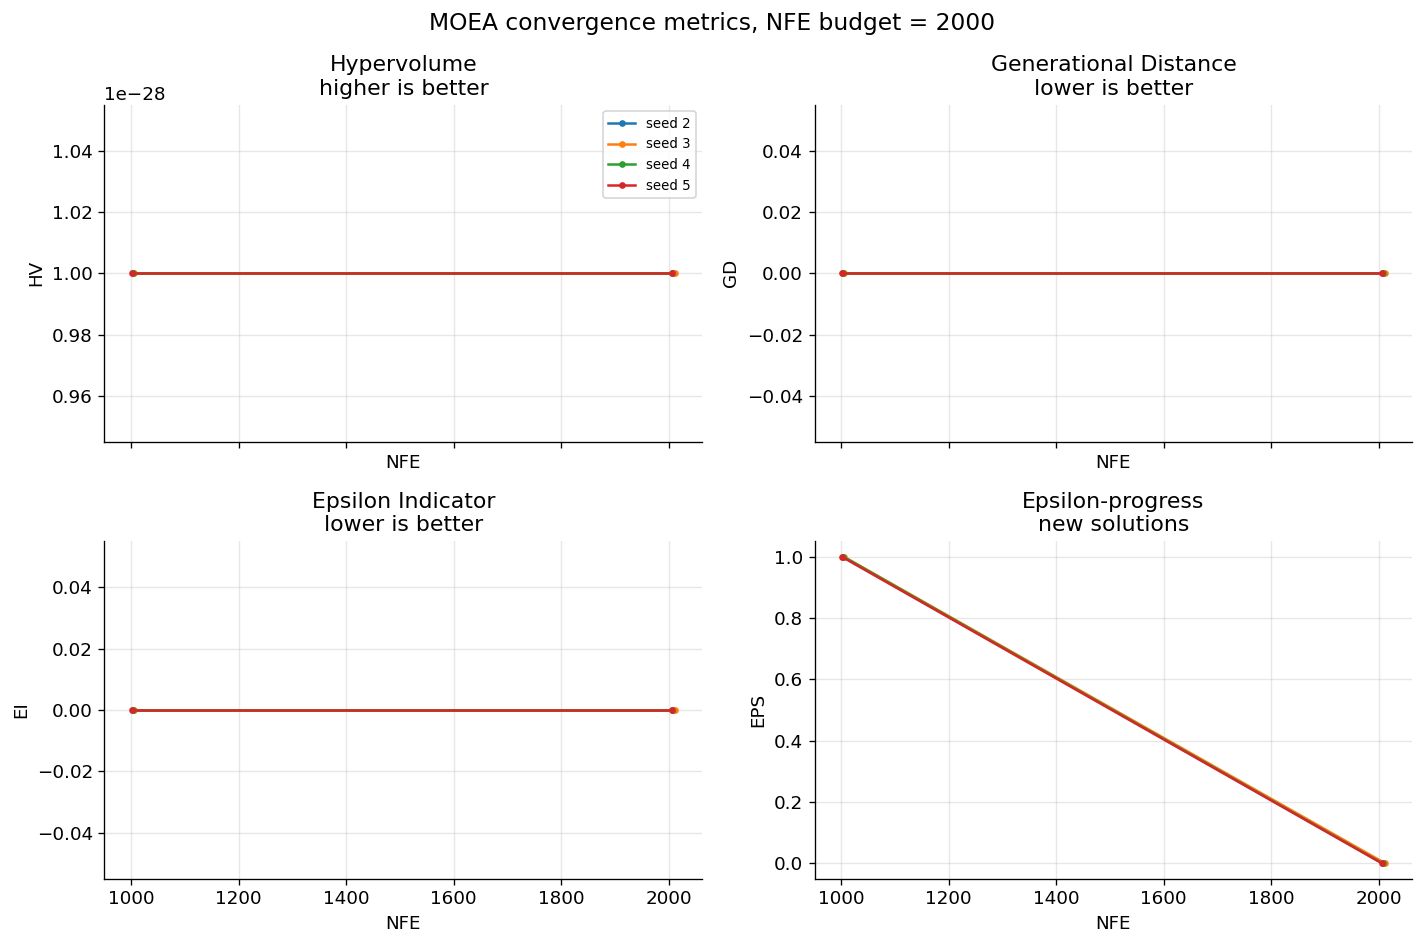

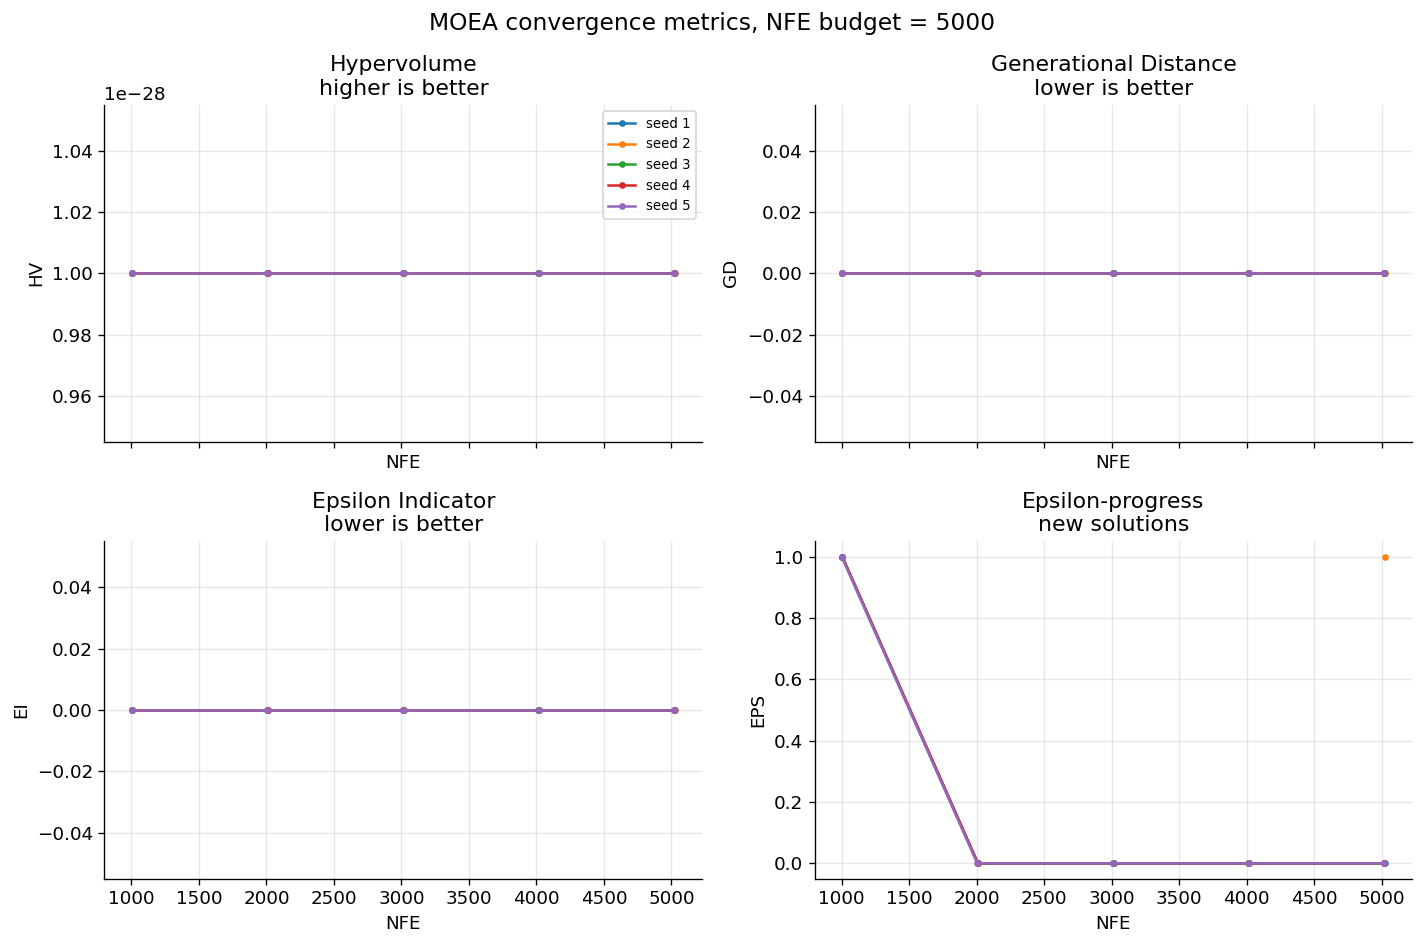

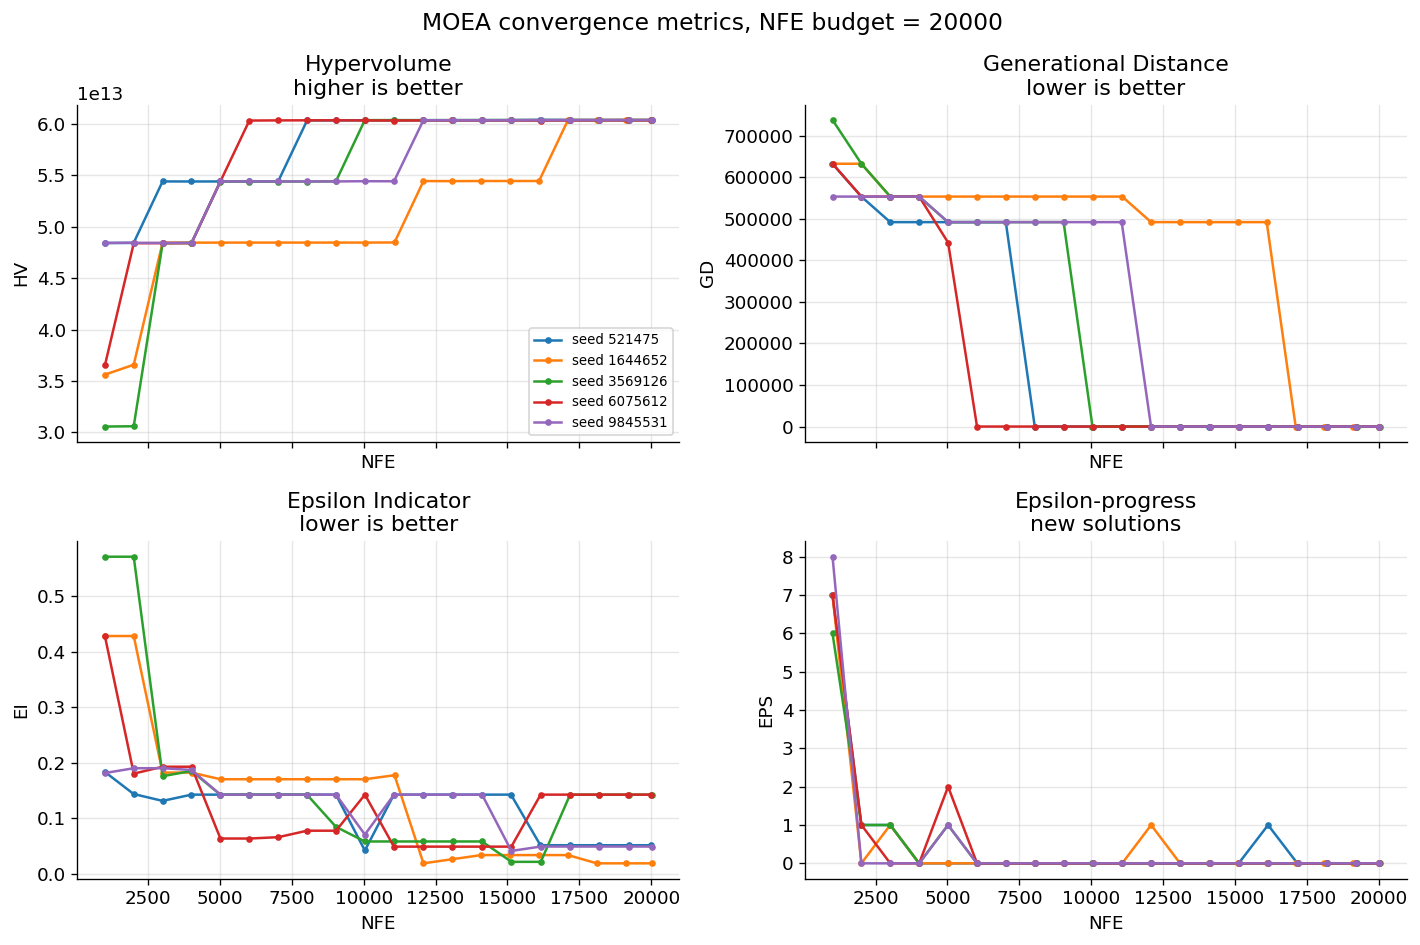

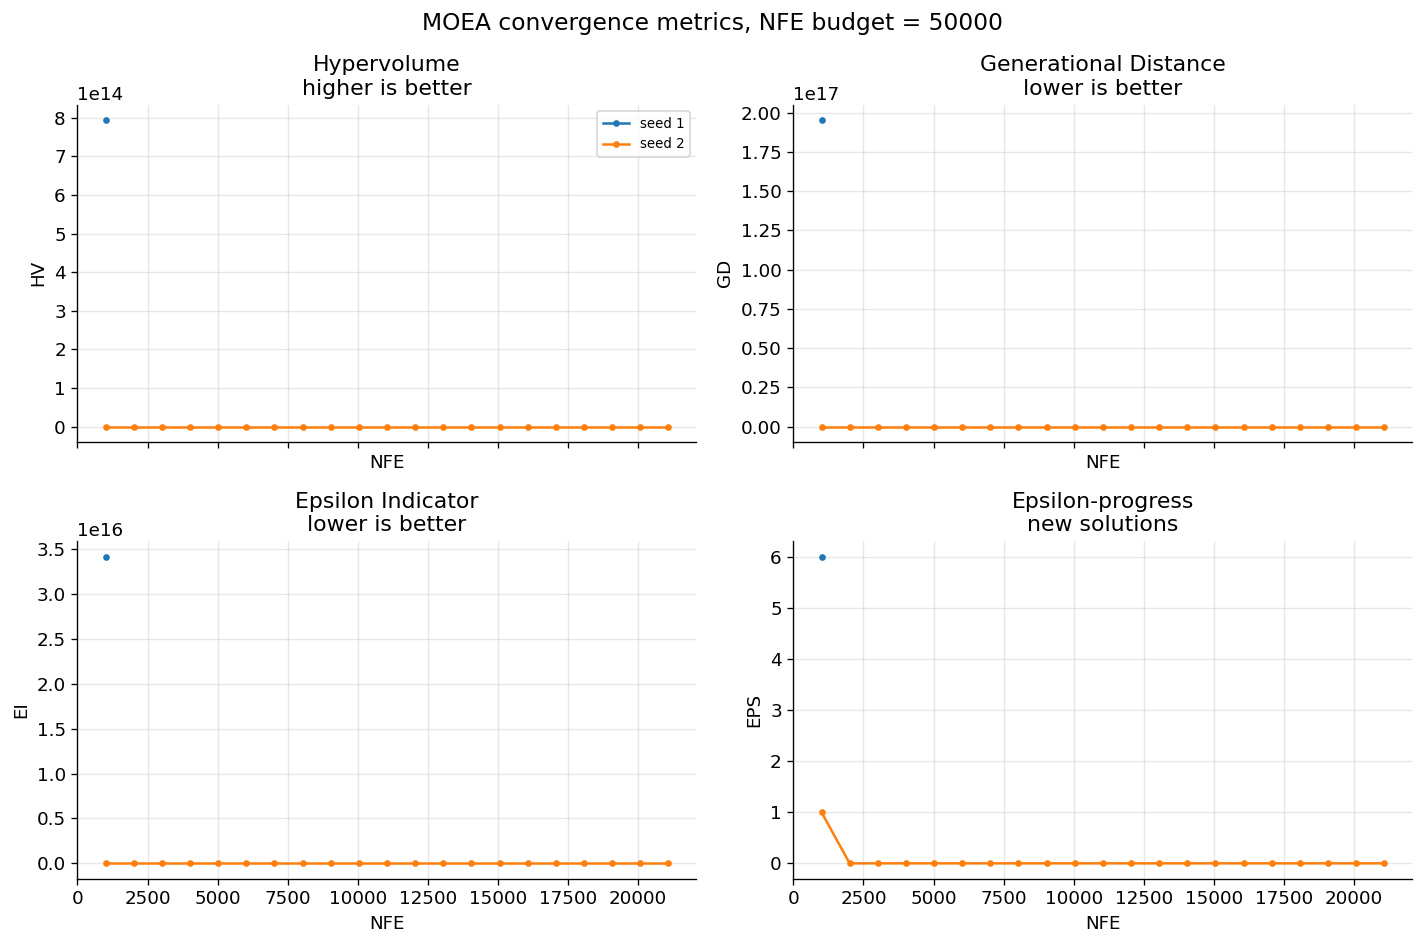

In [22]:
# ── Visualise Convergence Metrics ────────────────────────────────────────────

metric_specs = [
    ("hv",  "Hypervolume", "higher is better"),
    ("gd",  "Generational Distance", "lower is better"),
    ("ei",  "Epsilon Indicator", "lower is better"),
    ("eps", "Epsilon-progress", "new solutions"),
]

for nfe_budget, df_budget in metrics.groupby("nfe_budget"):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.ravel()

    for ax, (metric, title, subtitle) in zip(axes, metric_specs):
        for seed, df_seed in df_budget.groupby("seed"):
            df_seed = df_seed.sort_values("nfe")
            ax.plot(
                df_seed["nfe"],
                df_seed[metric],
                marker="o",
                linewidth=1.5,
                markersize=3,
                label=f"seed {seed}",
            )

        ax.set_title(f"{title}\n{subtitle}")
        ax.set_xlabel("NFE")
        ax.set_ylabel(metric.upper())
        ax.grid(alpha=0.3)

    axes[0].legend(loc="best", fontsize=8)

    fig.suptitle(f"MOEA convergence metrics, NFE budget = {nfe_budget}", fontsize=14)
    fig.tight_layout()
    plt.show()

Interpret the plots
>your answer here


---

## Reflection Questions

**1. Hypervolume convergence.** Does the hypervolume plateau before the NFE budget is exhausted, or is it still growing? What change to the optimisation setup would you recommend if HV was still rising at the final NFE?

**2. Epsilon-progress.** At what approximate NFE does epsilon-progress first reach zero (or near-zero)? Is this consistent with what you see in the hypervolume curve? Explain.

**3. Seed consistency.** If multiple seeds produce very different final hypervolumes within the same NFE group, what does that suggest about (a) the landscape of the objective space, and (b) the reliability of any single seed as a representative Pareto front?
